# HealthConnect Clinic — No-Show Prediction: Week 4 Exploratory Data Analysis

**Track:** Data Science
**Project:** AnalystLab Africa — HealthConnect Clinic Experience Lab
**Week:** Week 4 — Project Kickoff & Problem Understanding

This notebook performs the initial data assessment and exploratory data analysis (EDA) that supports
the `HealthConnect_ML_Problem_Definition_Week4.docx` document. It covers:

1. Dataset overview (shape, types, structure)
2. Data quality assessment (missing values, duplicates, logical consistency)
3. Target variable (`appointment_outcome`) distribution
4. Relationship between candidate features and the no-show outcome
5. Summary of findings feeding into the ML problem definition

> Scope note: per the Week 4 brief, this stage is about understanding the data and defining the
> modelling problem — not building or evaluating a final model. A baseline model is not fitted here;
> that begins in the next phase.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
df.shape


(5000, 18)

## 1. Dataset Overview

In [3]:
df.head()


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [4]:
df.dtypes


appointment_id               str
patient_id                   str
gender                       str
age                        int64
age_group                    str
appointment_type             str
booking_date                 str
appointment_date             str
appointment_day              str
appointment_time             str
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent                str
reminder_channel             str
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome          str
dtype: object

In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appointment_id,5000,5000,HC-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,5000,1696,P-1776,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,5000,3,Female,2488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,48.7948,18.138547,18.0,33.0,49.0,64.0,80.0
age_group,5000,6,65+,1241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_type,5000,4,General Consultation,2086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,5000,593,8/24/2025,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_date,5000,545,3/14/2026,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_day,5000,7,Wednesday,737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_time,5000,3,Morning,2227,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Quality Assessment

Checks performed: missing values, duplicate records, logical consistency between related fields,
and date-logic validation (booking date vs. appointment date).


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')


,missing_count,missing_pct
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


In [7]:
# Duplicate checks
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated appointment_id:", df['appointment_id'].duplicated().sum())
print("Unique patients:", df['patient_id'].nunique(), "across", len(df), "appointments")
print("Average appointments per patient:", round(len(df) / df['patient_id'].nunique(), 2))


Fully duplicated rows: 0
Duplicated appointment_id: 0
Unique patients: 1696 across 5000 appointments
Average appointments per patient: 2.95


In [8]:
# Logical consistency: previous_no_shows should never exceed previous_appointments
inconsistent = (df['previous_no_shows'] > df['previous_appointments']).sum()
print("Rows where previous_no_shows > previous_appointments:", inconsistent)

# Date logic: booking_date should never be after appointment_date
df['booking_date_dt'] = pd.to_datetime(df['booking_date'])
df['appointment_date_dt'] = pd.to_datetime(df['appointment_date'])
bad_dates = (df['booking_date_dt'] > df['appointment_date_dt']).sum()
print("Rows where booking_date is after appointment_date:", bad_dates)

# Cross-check booking_lead_days against the date difference
df['calc_lead_days'] = (df['appointment_date_dt'] - df['booking_date_dt']).dt.days
lead_mismatch = (df['calc_lead_days'] != df['booking_lead_days']).sum()
print("Rows where booking_lead_days does not match the date difference:", lead_mismatch)

# reminder_sent vs reminder_channel logic: channel should be null only when no reminder was sent
print()
print(pd.crosstab(df['reminder_sent'], df['reminder_channel'].isna(), rownames=['reminder_sent'], colnames=['channel_is_missing']))


Rows where previous_no_shows > previous_appointments: 0
Rows where booking_date is after appointment_date: 0
Rows where booking_lead_days does not match the date difference: 0

channel_is_missing  False  True 
reminder_sent                   
No                      0   1366
Yes                  3634      0


**Data quality summary:**
- No fully duplicated rows and no duplicated `appointment_id` values.
- `previous_no_shows` never exceeds `previous_appointments` — internally consistent.
- No date-logic violations: `booking_date` is never after `appointment_date`, and `booking_lead_days`
  matches the calculated date difference in every row.
- `reminder_channel` is missing only where `reminder_sent = No`, which is expected (no reminder → no channel),
  not a data quality defect — however it does mean `reminder_channel` cannot be used as a feature on its own
  without accounting for this structural relationship with `reminder_sent`.
- `distance_to_clinic_km` and `waiting_time_minutes` have a small proportion of genuinely missing values
  (~1.8% and ~1.2% respectively) that will need imputation or row exclusion before modelling.
- Each patient appears an average of ~3 times in the dataset — **this matters for train/test
  splitting**: a naive random split could place the same patient's appointments in both training and
  test sets, leaking patient-specific behaviour and inflating apparent performance. A **group-aware split
  (by `patient_id`) or a chronological split** is required, not a plain random split.


## 3. Target Variable: `appointment_outcome`

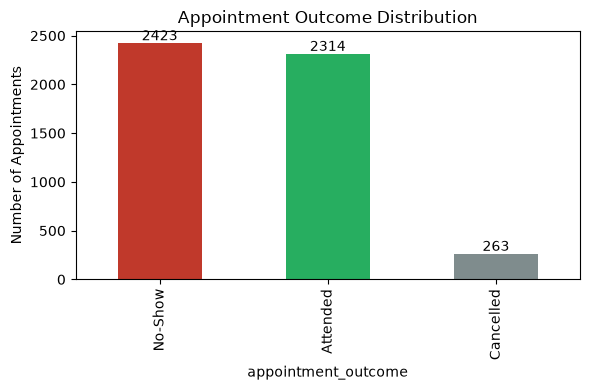

                     count   pct
appointment_outcome             
No-Show               2423  48.5
Attended              2314  46.3
Cancelled              263   5.3


In [9]:
outcome_counts = df['appointment_outcome'].value_counts()
outcome_pct = df['appointment_outcome'].value_counts(normalize=True).round(3) * 100

fig, ax = plt.subplots(figsize=(6,4))
outcome_counts.plot(kind='bar', color=['#c0392b', '#27ae60', '#7f8c8d'], ax=ax)
ax.set_title('Appointment Outcome Distribution')
ax.set_ylabel('Number of Appointments')
for i, v in enumerate(outcome_counts):
    ax.text(i, v + 30, str(v), ha='center')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'count': outcome_counts, 'pct': outcome_pct}))


**Observation:** the three-way outcome splits roughly as **48.5% No-Show, 46.3% Attended,
5.3% Cancelled**. Unlike many published healthcare no-show datasets, no-shows are **not a small
minority class here** — they are almost exactly as common as attendance. This is a materially
important finding versus the Week 4 problem-definition assumption of a heavily imbalanced target,
and it simplifies the modelling approach (less need for aggressive class-imbalance handling).

`Cancelled` appointments are a small, separate category (~5%) and support the earlier proposal to model
them separately from true no-shows.


## 4. Target Variable Definition for Modelling

In [10]:
# Binary target: is_no_show = 1 if the outcome was a genuine no-show, else 0
# Cancelled appointments are excluded from the primary binary model (see Section 6 of the
# ML Problem Definition document) and analysed separately below for completeness.
df_model = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_model['is_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

print("Rows available for binary modelling (Attended + No-Show):", len(df_model))
print("Class balance:")
print(df_model['is_no_show'].value_counts(normalize=True).round(3))


Rows available for binary modelling (Attended + No-Show): 4737
Class balance:
is_no_show
1    0.512
0    0.488
Name: proportion, dtype: float64


## 5. Candidate Feature Exploration

### 5.1 Numeric features vs. no-show

In [11]:
numeric_cols = ['age', 'booking_lead_days', 'previous_appointments',
                'previous_no_shows', 'distance_to_clinic_km', 'waiting_time_minutes']

df_model[numeric_cols + ['is_no_show']].corr()['is_no_show'].sort_values(ascending=False)


is_no_show               1.000000
booking_lead_days        0.287255
previous_no_shows        0.122892
distance_to_clinic_km    0.065213
previous_appointments    0.042421
waiting_time_minutes    -0.004062
age                     -0.028446
Name: is_no_show, dtype: float64

**Observation:** `booking_lead_days` shows the strongest correlation with no-shows (~0.27),
followed by `previous_no_shows` (~0.13). `distance_to_clinic_km`, `previous_appointments`, and
`age` show weak correlations. `waiting_time_minutes` shows essentially no linear relationship —
this makes sense, since waiting time is only known *after* an appointment starts and would in any
case not be usable as a prediction-time feature (see leakage note in the ML Problem Definition doc).


             no_show_rate     n
lead_bucket                    
(-1, 7]             0.295   604
(7, 14]             0.352   574
(14, 21]            0.429   574
(21, 30]            0.478   691
(30, 45]            0.570  1187
(45, 60]            0.714  1107


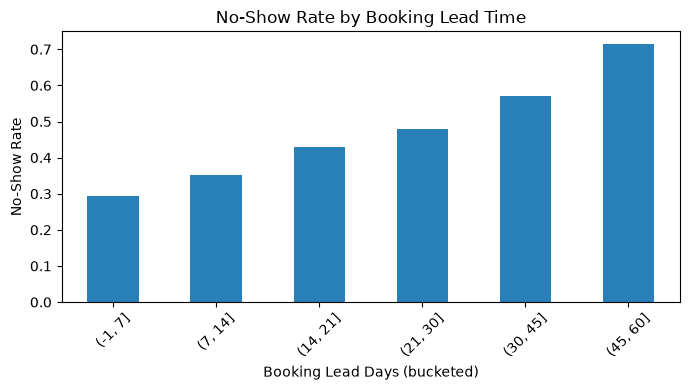

In [12]:
# booking_lead_days: no-show rate by lead-time bucket
df_model['lead_bucket'] = pd.cut(df_model['booking_lead_days'], bins=[-1,7,14,21,30,45,60])
lead_rate = df_model.groupby('lead_bucket', observed=True)['is_no_show'].agg(no_show_rate='mean', n='count').round(3)
print(lead_rate)

fig, ax = plt.subplots(figsize=(7,4))
lead_rate['no_show_rate'].plot(kind='bar', color='#2980b9', ax=ax)
ax.set_title('No-Show Rate by Booking Lead Time')
ax.set_ylabel('No-Show Rate')
ax.set_xlabel('Booking Lead Days (bucketed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** a clear, monotonic relationship — no-show rate rises from **~28% for
appointments booked 0–7 days ahead to ~68% for appointments booked 45–60 days ahead**. This is the
single strongest and most actionable pattern found in Week 4 EDA: appointments booked far in advance
are substantially more likely to be missed.


In [13]:
# previous_no_shows: no-show rate by prior no-show count
prev_rate = df_model.groupby('previous_no_shows')['is_no_show'].agg(no_show_rate='mean', n='count').round(3)
print(prev_rate)


                   no_show_rate     n
previous_no_shows                    
0                         0.463  2745
1                         0.559  1482
2                         0.621   419
3                         0.697    76
4                         0.667    12
5                         1.000     3


**Observation:** no-show rate rises steadily with prior no-show history — from ~44% for
patients with zero prior no-shows to ~68% for patients with 3 prior no-shows (small sample sizes
at the higher counts should be treated with caution). This confirms the standard finding that past
behaviour is predictive of future behaviour and supports including `previous_no_shows` (or a derived
`previous_no_show_rate`) as a feature.


### 5.2 Categorical features vs. no-show

In [14]:
categorical_cols = ['gender', 'appointment_type', 'appointment_day', 'appointment_time',
                    'reminder_sent', 'reminder_channel', 'age_group']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df_model.groupby(col, observed=True)['is_no_show'].agg(no_show_rate='mean', n='count').round(3))
    print()


--- gender ---
                   no_show_rate     n
gender                               
Female                    0.511  2358
Male                      0.515  2274
Prefer not to say         0.448   105

--- appointment_type ---
                         no_show_rate     n
appointment_type                           
Diagnostic Test                 0.520   567
Follow-up                       0.542  1344
General Consultation            0.491  1980
Specialist Consultation         0.505   846

--- appointment_day ---
                 no_show_rate    n
appointment_day                   
Friday                  0.487  696
Monday                  0.531  655
Saturday                0.496  683
Sunday                  0.528  704
Thursday                0.520  644
Tuesday                 0.489  662
Wednesday               0.528  693

--- appointment_time ---
                  no_show_rate     n
appointment_time                    
Afternoon                0.512  1979
Evening                  0.5

**Observation:** the categorical fields explored (gender, appointment type, day of week,
time of day, reminder channel, age group) all show **relatively flat no-show rates**, typically
within a 4–6 percentage-point band of one another. This suggests these fields individually carry
limited standalone predictive power in this dataset, although they may still contribute value in
combination with other features, and `reminder_sent` / `reminder_channel` remain operationally
relevant even if not strongly predictive (the clinic still wants to know whether reminders reduce
no-shows, which is a causal question the Analysis phase can look at more rigorously).


## 6. Summary of Week 4 EDA Findings

1. **Data quality is good.** No duplicate records, no logical inconsistencies between
   related fields, and only small amounts of missing data (~1–2%) in `distance_to_clinic_km` and
   `waiting_time_minutes`.
2. **The target is close to balanced** (48.5% No-Show vs. 46.3% Attended), which was not assumed
   at the start of Week 4 and simplifies class-imbalance handling in later modelling.
3. **`booking_lead_days` is the strongest single predictor found so far** — no-show rate rises
   sharply as lead time increases.
4. **`previous_no_shows` is the second strongest predictor** — prior behaviour predicts future
   behaviour.
5. **Categorical fields (gender, appointment type, day/time, reminder channel) show weak
   standalone relationships** with the outcome in this dataset.
6. **`patient_id` repetition (avg. ~3 appointments/patient) requires a group-aware or
   chronological train/test split**, not a random row-level split, to avoid leakage.
7. **`Cancelled` appointments (~5%) are proposed to be excluded from the primary binary model**
   and analysed as a separate category, per Section 6 of the ML Problem Definition document.

These findings will be used to finalise feature engineering and the baseline model in the next
phase of the project (Analysis and Solution Design).
